# Desafio: bora praticar?

O time de ML chegou com algumas demandas de última hora para resolvermos neste momento da análise exploratória:

1. Calcular a média de quartos dos imóveis;
2. Conferir quantos bairros únicos existem na nossa base de dados;
3. Analisar quais bairros possuem a média de valor de aluguel mais elevadas;
4. Criar um gráfico de barras horizontais que apresente os 5 bairros com as médias de valores de aluguel mais elevadas.

## Preparando a base de dados

Importamos a mesma base de aluguel usada no notebook principal, para os desafios rodarem de forma independente.

In [3]:
import pandas as pd

url = 'https://raw.githubusercontent.com/alura-cursos/pandas-conhecendo-a-biblioteca/main/base-de-dados/aluguel.csv'
dados = pd.read_csv(url, sep=';')
dados.head()

,Tipo,Bairro,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU
0,Quitinete,Copacabana,1,0,0,40,1700.0,500.0,60.0
1,Casa,Jardim Botânico,2,0,1,100,7000.0,NaN,NaN
2,Conjunto Comercial/Sala,Barra da Tijuca,0,4,0,150,5200.0,4020.0,1111.0
3,Apartamento,Centro,1,0,0,15,800.0,390.0,20.0
4,Apartamento,Higienópolis,1,0,0,48,800.0,230.0,NaN


## Desafio 1 — Qual a média de quartos dos imóveis?

Selecionamos a coluna `Quartos` e aplicamos `.mean()` para obter a média aritmética.

In [4]:
dados['Quartos'].mean()

np.float64(1.7713895631067962)

## Desafio 2 — Quantos bairros únicos existem na base?

In [5]:
dados['Bairro'].nunique()

162

## Desafio 3 — Quais bairros têm as médias de aluguel mais elevadas?

In [6]:
df_preco_bairro = dados.groupby('Bairro')[['Valor']].mean().sort_values('Valor', ascending=False)

df_preco_bairro

,Valor
Bairro,
Jacarepaguá,314143.489637
Irajá,154610.470588
Caju,120264.782609
Vasco da Gama,120000.000000
Cidade Nova,88166.692308
...,...
Inhoaíba,738.888889
Turiaçu,733.333333
Magalhães Bastos,726.666667


## Desafio 4 — Gráfico dos 5 bairros com maior média de aluguel

<Axes: title={'center': 'Top 5 bairros com maior média de aluguel'}, ylabel='Bairro'>

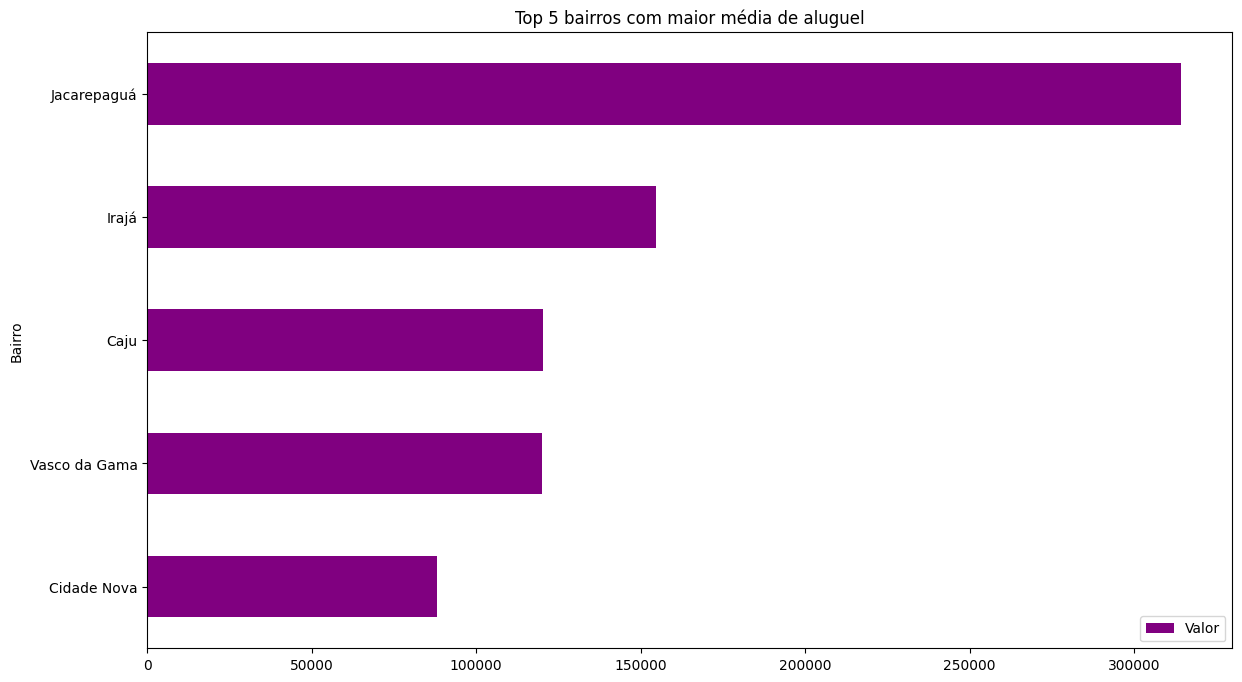

In [7]:
# Pega os 5 bairros mais caros e reordena de forma crescente,
# para que a maior barra apareça no topo do gráfico horizontal
df_top5_bairros = df_preco_bairro.head(5).sort_values('Valor')

df_top5_bairros.plot(
    kind='barh',
    figsize=(14, 8),
    color='purple',
    title='Top 5 bairros com maior média de aluguel'
)

# 🎓 Desafio extra — Tratamento e seleção com `alunos.csv`

Praticando os métodos da aula com um **dataset diferente**: notas de alunos de um curso superior (`dados/alunos.csv`, mesmo arquivo dos desafios da aula 1).

1. Verificar e tratar os dados nulos da forma mais coerente;
2. Remover os alunos **"Alice"** e **"Carlos"** (não fazem mais parte da turma);
3. Filtrar apenas os alunos **aprovados**;
4. Salvar os aprovados em `alunos_aprovados.csv`;
5. **Extra:** substituir as notas `7.0` por `8.0` (ponto extra não contabilizado), usando o método `replace`.

In [ ]:
import pandas as pd

df_alunos = pd.read_csv('../dados/alunos.csv')
df_alunos

## Parte 1 — Verificar e tratar os dados nulos

Localizamos os nulos com `isnull().sum()`. A coluna `Notas` tem **6 ausências** — e todos esses alunos têm `Aprovado = False`.

**Tratamento coerente:** quem não tem nota registrada não realizou a avaliação e, portanto, não pontuou. O mais coerente aqui é preencher essas notas com `0` usando `fillna(0)` — assim a coluna fica completa e numérica, sem inventar notas que distorçam a análise (preencher com a média, por exemplo, "premiaria" quem não fez a prova).

In [ ]:
# Localiza os nulos: a coluna Notas tem 6 ausências
df_alunos.isnull().sum()

In [ ]:
# Preenche as notas ausentes com 0 e confirma que não há mais nulos
df_alunos = df_alunos.fillna(0)
df_alunos.isnull().sum()

## Parte 2 — Remover os alunos "Alice" e "Carlos"

Eles não fazem mais parte da turma. Usamos `.isin(['Alice', 'Carlos'])` para marcar essas linhas e o operador `~` (negação) para **manter todos os outros** — o oposto de um filtro comum. Reatribuímos a `df_alunos` para seguir trabalhando já sem eles.

In [ ]:
# isin() marca quem está na lista; ~ inverte, mantendo todos os outros alunos
df_alunos = df_alunos[~df_alunos['Nome'].isin(['Alice', 'Carlos'])]
df_alunos